# 34 — Inside the Insulin Group: What Affects Their Diabetes Control?

**Purpose**: Across NB28–33 the insulin-dependent group is always one of four buckets. NB30 hinted
that depressed insulin patients had worse HbA1c, but it never *isolated* the insulin group to ask
the direct question: **among insulin-dependent patients specifically, which clinical, psychosocial,
and behavioral factors line up with better or worse blood-sugar control?**

**Why this matters**: Insulin patients have the hardest disease to manage and the highest
psychosocial burden. Knowing what separates well-controlled from poorly-controlled insulin patients
points to where support could help most.

**⚠️ Honest expectation**: the insulin group is small (n=258), so within-group signals are modest
and most will not survive multiple-testing correction. We report effect sizes **with bootstrap
confidence intervals** so the uncertainty from this small sample is visible, not hidden.

**Self-contained**: Loads directly from Azure — no dependency on prior notebooks. All outcomes are
lab/manifest-based (HbA1c, mean glucose) so the cells run fast (no CGM streaming).

**Inputs**:
- `participants.tsv` (study group) · `person.csv` (age)
- `observation.csv` — CES-D-10, PAID-5, education, food insecurity, comorbidities
- `measurement.csv` — HbA1c, BMI, MoCA
- `wearable_blood_glucose/manifest.tsv` — mean glucose · `wearable_activity_monitor/manifest.tsv` — steps/sleep/stress

---

**Table of Contents**
1. Environment Setup
2. Azure Connection & Data Load
3. Build the Insulin-Group Master DataFrame
4. Analysis 1 — Insulin Control Profile (how well controlled are they?)
5. Analysis 2 — Univariate Correlates of Control (Spearman + FDR + bootstrap CIs)
6. Analysis 3 — Spotlight: Diabetes Distress & Education
7. Analysis 4 — Well-Controlled vs Poorly-Controlled Insulin Patients
8. Analysis 5 — Multivariate Regression: What Holds Up Independently?
9. Key Findings

---

In [1]:
# ── 1. Environment Setup ────────────────────────────────────────────
import subprocess, sys

for pkg in ['azure-storage-blob', 'seaborn', 'scipy', 'python-dotenv', 'statsmodels']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, re, warnings, getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy.stats import mannwhitneyu, spearmanr, kruskal
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
import statsmodels.api as sm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER   = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP     = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_STR_MAP = {
    'healthy': 0, 'prediabetes': 1, 'pre-diabetes': 1, 'pre_diabetes': 1,
    'oral medication': 2, 'oral_medication': 2, 'non-insulin': 2,
    'insulin': 3, 'insulin-dependent': 3,
    'pre_diabetes_lifestyle_controlled': 1,
    'oral_medication_and_or_non_insulin_injectable_medication_controlled': 2,
    'insulin_dependent': 3,
}
GROUP_COLORS = {'Healthy': '#66C2A5', 'Pre-DM': '#4DAFFA', 'Oral Med': '#F5A623', 'Insulin': '#E8413E'}

# Control thresholds (HbA1c %)
HBA1C_WELL = 7.0   # < 7%  = well controlled
HBA1C_POOR = 8.0   # >= 8% = poorly controlled

# Outcomes (higher = worse control) and candidate predictors
OUTCOMES = {'hba1c': 'HbA1c (%)', 'mean_glucose': 'Mean glucose (mg/dL)'}
PREDICTORS = {
    'paid_total':        'Diabetes distress (PAID-5)',
    'education':         'Years of education',
    'cesd_total':        'Depression (CES-D-10)',
    'moca_total':        'Cognition (MoCA)',
    'comorbidity_count': 'Comorbidity count',
    'age':               'Age (years)',
    'bmi':               'BMI',
    'steps':             'Daily steps',
    'sleep':             'Sleep hours',
    'stress':            'Stress level',
    'food_insec':        'Food insecurity',
}

STUDY_ID = '1438dd73-c4cb-48b8-8fa8-c858771207c3'
print('Environment ready.')

Environment ready.


In [2]:
# ── 2. Azure Connection & Data Load ───────────────────────────────
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv

IN_COLAB = os.path.exists('/content')
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME = 'aireadi-container'
else:
    _cwd = Path.cwd()
    repo_root = str(_cwd if (_cwd / 'config').exists() else _cwd.parent if (_cwd.parent / 'config').exists() else _cwd)
    _env_path = Path(repo_root) / '.env'
    load_dotenv(_env_path, override=True)
    CONNECTION_STRING = os.getenv('AZURE_STORAGE_CONNECTION_STRING', '')
    CONTAINER_NAME    = os.getenv('AZURE_CONTAINER_NAME', 'aireadi-container')
    STUDY_ID          = os.getenv('AZURE_STUDY_ID', STUDY_ID)
    print(f'.env found={_env_path.exists()}  |  repo_root={repo_root}')
    if not CONNECTION_STRING:
        raise ValueError('AZURE_STORAGE_CONNECTION_STRING empty — check .env')

container = BlobServiceClient.from_connection_string(CONNECTION_STRING).get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    data = container.get_blob_client(blob_path).download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('\nLoading participants.tsv ...')
participants = load_blob_csv(f'{STUDY_ID}/dataset/participants.tsv', sep='\t')
sg_col = next((c for c in participants.columns if 'study' in c.lower()), None)
participants['study_group_code']  = participants[sg_col].str.lower().str.strip().map(STUDY_GROUP_STR_MAP)
participants['study_group_label'] = pd.Categorical(
    participants['study_group_code'].map(STUDY_GROUP_MAP), categories=STUDY_GROUP_ORDER, ordered=True)
participants['person_id'] = participants['person_id'].astype(str)
print(f'  {len(participants):,} participants')

print('Loading person.csv ...')
person = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/person.csv', usecols=['person_id', 'year_of_birth'])
person['age'] = 2024 - person['year_of_birth']
person['person_id'] = person['person_id'].astype(str)

print('Loading observation.csv ...')
obs_raw = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/observation.csv',
                        usecols=['person_id', 'observation_source_value', 'value_as_number'])
obs_raw['person_id'] = obs_raw['person_id'].astype(str)

print('Loading measurement.csv ...')
meas_raw = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/measurement.csv',
                         usecols=['person_id', 'measurement_source_value', 'value_as_number'])
meas_raw['person_id'] = meas_raw['person_id'].astype(str)

print('Loading wearable manifests ...')
cgm_manifest  = load_blob_csv(f'{STUDY_ID}/dataset/wearable_blood_glucose/manifest.tsv', sep='\t')
act_manifest  = load_blob_csv(f'{STUDY_ID}/dataset/wearable_activity_monitor/manifest.tsv', sep='\t')
cgm_manifest['person_id'] = cgm_manifest['person_id'].astype(str)
act_manifest['person_id'] = act_manifest['person_id'].astype(str)
print('  done')

.env found=True  |  repo_root=/Users/evanlee/Desktop/ucsf-tech-aireadi

Loading participants.tsv ...
  2,280 participants
Loading person.csv ...
Loading observation.csv ...
Loading measurement.csv ...
Loading wearable manifests ...
  done


In [3]:
# ── 3. Build the Insulin-Group Master DataFrame ───────────────────
# Observation items (split label before first comma)
obs_raw['item_key']    = obs_raw['observation_source_value'].astype(str).str.split(',', n=1).str[0].str.strip().str.lower()
obs_raw['value_clean'] = pd.to_numeric(obs_raw['value_as_number'], errors='coerce')
obs_raw.loc[obs_raw['value_clean'] == 99, 'value_clean'] = np.nan
def o1(k): return obs_raw[obs_raw['item_key'] == k].groupby('person_id')['value_clean'].first()
cesd_total = o1('cestl').rename('cesd_total')
paid_total = o1('paidscore').rename('paid_total')
education  = o1('years_of_education').rename('education')
food_insec = o1('food_insecurity_change_diet_frequency').rename('food_insec')
mh = obs_raw[obs_raw['item_key'].str.startswith('mhoccur', na=False)]
dcols = [c for c in mh['item_key'].unique() if 'fallot' not in c and c != 'mhoccur_yn']
comorbidity_count = (mh[mh['item_key'].isin(dcols)]
                     .pivot_table(index='person_id', columns='item_key', values='value_clean', aggfunc='first')
                     .clip(upper=1).sum(axis=1).rename('comorbidity_count'))

# Measurement items
meas_raw['mkey'] = meas_raw['measurement_source_value'].astype(str).str.split(',', n=1).str[0].str.strip().str.lower()
meas_raw['mval'] = pd.to_numeric(meas_raw['value_as_number'], errors='coerce')
def m1(k): return meas_raw[meas_raw['mkey'] == k].groupby('person_id')['mval'].first()
hba1c      = m1('import_hba1c').rename('hba1c')
bmi        = m1('bmi_vsorres').rename('bmi')
moca_total = m1('moca_total_score').rename('moca_total')

# Manifest metrics
mean_glucose = pd.to_numeric(cgm_manifest.set_index('person_id')['average_glucose_level_mg_dl'], errors='coerce').rename('mean_glucose')
steps  = pd.to_numeric(act_manifest.set_index('person_id')['average_daily_activity'], errors='coerce').rename('steps')
sleep  = pd.to_numeric(act_manifest.set_index('person_id')['average_sleep_hours'], errors='coerce').rename('sleep')
stress = pd.to_numeric(act_manifest.set_index('person_id')['average_stress_level'], errors='coerce').rename('stress')

# Merge everything onto participants
df = participants[['person_id', 'study_group_code', 'study_group_label']].merge(
        person[['person_id', 'age']], on='person_id', how='left')
for s in [cesd_total, paid_total, education, food_insec, comorbidity_count,
          hba1c, bmi, moca_total, mean_glucose, steps, sleep, stress]:
    df = df.merge(s.rename(s.name).reset_index().rename(columns={'index': 'person_id'}), on='person_id', how='left')

# Control flags
df['poorly_controlled'] = (df['hba1c'] >= HBA1C_POOR).astype('float')
df['well_controlled']   = (df['hba1c'] <  HBA1C_WELL).astype('float')

# Insulin-only frame
ins = df[df['study_group_label'] == 'Insulin'].copy()

print(f'Full cohort: {len(df):,}  |  INSULIN group: {len(ins):,}')
print(f"\nInsulin control outcomes:")
print(f"  HbA1c        : {ins['hba1c'].notna().sum()} scored, mean {ins['hba1c'].mean():.2f}%  "
      f"(<7%: {(ins['hba1c']<HBA1C_WELL).mean()*100:.0f}%, ≥8%: {(ins['hba1c']>=HBA1C_POOR).mean()*100:.0f}%, ≥9%: {(ins['hba1c']>=9).mean()*100:.0f}%)")
print(f"  Mean glucose : {ins['mean_glucose'].notna().sum()} scored, mean {ins['mean_glucose'].mean():.1f} mg/dL")
print(f"\nPredictor coverage within insulin (n={len(ins)}):")
for col, label in PREDICTORS.items():
    n = ins[col].notna().sum() if col in ins.columns else 0
    flag = '✅' if n >= 30 else '⚠️ '
    print(f"  {flag} {label:<28}: {n:3d} ({n/len(ins)*100:.0f}%)")

Full cohort: 2,280  |  INSULIN group: 258

Insulin control outcomes:
  HbA1c        : 248 scored, mean 7.38%  (<7%: 47%, ≥8%: 23%, ≥9%: 17%)
  Mean glucose : 251 scored, mean 175.6 mg/dL

Predictor coverage within insulin (n=258):
  ✅ Diabetes distress (PAID-5)  : 254 (98%)
  ✅ Years of education          : 255 (99%)
  ✅ Depression (CES-D-10)       : 256 (99%)
  ✅ Cognition (MoCA)            : 256 (99%)
  ✅ Comorbidity count           : 258 (100%)
  ✅ Age (years)                 : 258 (100%)
  ✅ BMI                         : 257 (100%)
  ✅ Daily steps                 : 243 (94%)
  ✅ Sleep hours                 : 247 (96%)
  ✅ Stress level                : 240 (93%)
  ✅ Food insecurity             :  46 (18%)


---
## 4. Analysis 1 — Insulin Control Profile

> **Question**: How well controlled is the insulin group, and how do they compare to the other
> diabetes groups? This sets the baseline before we ask *what* drives the variation.
>
> **Method**: Distribution of HbA1c and mean glucose within insulin, share well- vs
> poorly-controlled, and mean HbA1c across all four groups for context.

=== Insulin glycemic control ===
  HbA1c: n=248, mean 7.38%, median 7.00%
    well controlled (<7.0%): 49.2%
    7–8%:                            26.6%
    poorly controlled (≥8.0%): 24.2%
    very poor (≥9%):                 17.3%

=== Mean HbA1c by diabetes group (context) ===
                   count  mean
study_group_label             
Healthy              760 5.540
Pre-DM               546 5.850
Oral Med             657 6.550
Insulin              248 7.380


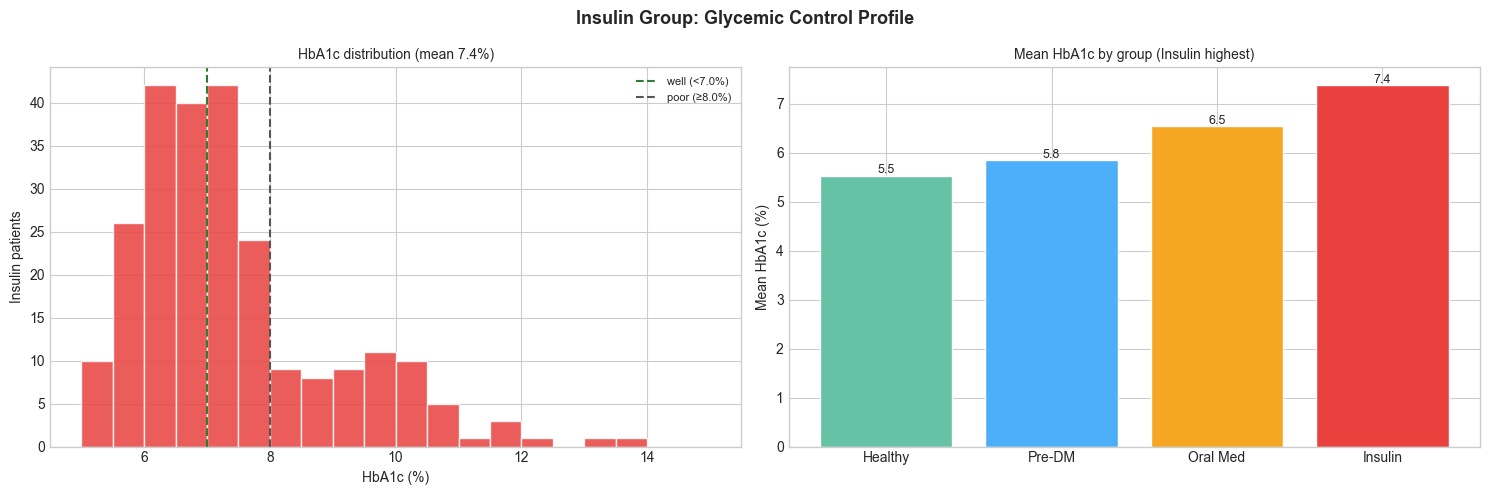

In [4]:
# ── Analysis 1: Insulin Control Profile ───────────────────────────
h = ins['hba1c'].dropna()
print('=== Insulin glycemic control ===')
print(f'  HbA1c: n={len(h)}, mean {h.mean():.2f}%, median {h.median():.2f}%')
print(f'    well controlled (<{HBA1C_WELL}%): {(h<HBA1C_WELL).mean()*100:.1f}%')
print(f'    7–8%:                            {((h>=HBA1C_WELL)&(h<HBA1C_POOR)).mean()*100:.1f}%')
print(f'    poorly controlled (≥{HBA1C_POOR}%): {(h>=HBA1C_POOR).mean()*100:.1f}%')
print(f'    very poor (≥9%):                 {(h>=9).mean()*100:.1f}%')

print('\n=== Mean HbA1c by diabetes group (context) ===')
ctx = df.groupby('study_group_label', observed=True)['hba1c'].agg(['count', 'mean']).round(2)
print(ctx.to_string())

# ── Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Insulin Group: Glycemic Control Profile', fontsize=13, fontweight='bold')
axes[0].hist(h, bins=np.arange(5, 15.5, 0.5), color='#E8413E', edgecolor='white', alpha=0.85)
axes[0].axvline(HBA1C_WELL, color='#2E7D32', ls='--', lw=1.5, label=f'well (<{HBA1C_WELL}%)')
axes[0].axvline(HBA1C_POOR, color='#555', ls='--', lw=1.5, label=f'poor (≥{HBA1C_POOR}%)')
axes[0].set_xlabel('HbA1c (%)'); axes[0].set_ylabel('Insulin patients')
axes[0].set_title(f'HbA1c distribution (mean {h.mean():.1f}%)', fontsize=10); axes[0].legend(fontsize=8)

means = df.groupby('study_group_label', observed=True)['hba1c'].mean().reindex(STUDY_GROUP_ORDER)
bars = axes[1].bar(STUDY_GROUP_ORDER, means.values, color=[GROUP_COLORS[g] for g in STUDY_GROUP_ORDER], edgecolor='white')
for b, v in zip(bars, means.values):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.05, f'{v:.1f}', ha='center', fontsize=9)
axes[1].set_ylabel('Mean HbA1c (%)'); axes[1].set_title('Mean HbA1c by group (Insulin highest)', fontsize=10)
plt.tight_layout(); plt.show()

---
## 5. Analysis 2 — Univariate Correlates of Control

> **Question**: Within the insulin group, which factors line up with worse control? (Higher HbA1c /
> mean glucose = worse, so a **positive** correlation = that factor goes with worse control.)
>
> **Method**: Spearman correlation of each candidate predictor with HbA1c and mean glucose,
> FDR-corrected across predictors, **with bootstrap 95% CIs** (5,000×) so the uncertainty from the
> small insulin sample is explicit. A CI that excludes 0 is the robust signal.


=== Predictors vs HbA1c (%) (within insulin) ===
(positive rho = factor associated with WORSE control)
                 predictor   n    rho     p  p_fdr  fdr_sig  ci_low  ci_high  CI_excludes_0
Diabetes distress (PAID-5) 244  0.153 0.017  0.130    False   0.021    0.271           True
        Years of education 246 -0.144 0.024  0.130    False  -0.262   -0.020           True
          Cognition (MoCA) 247 -0.086 0.178  0.517    False  -0.206    0.037          False
     Depression (CES-D-10) 246  0.084 0.188  0.517    False  -0.045    0.206          False
           Food insecurity  43 -0.064 0.682  0.792    False  -0.350    0.224          False
               Age (years) 248 -0.046 0.473  0.792    False  -0.175    0.079          False
                       BMI 247  0.043 0.501  0.792    False  -0.081    0.168          False
         Comorbidity count 248 -0.038 0.551  0.792    False  -0.167    0.086          False
               Sleep hours 237 -0.028 0.673  0.792    False  -0.159 

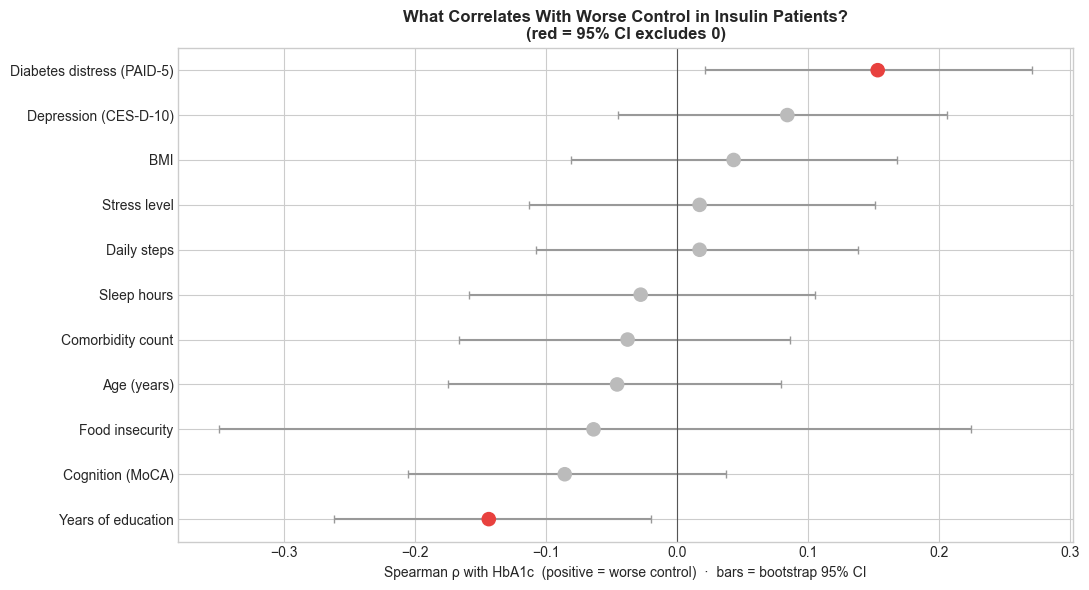

In [5]:
# ── Analysis 2: Univariate Correlates (Spearman + FDR + bootstrap CI) ──
def bootstrap_corr_ci(x, y, n_boot=5000, seed=0):
    x = np.asarray(x, float); y = np.asarray(y, float); n = x.size
    rng = np.random.default_rng(seed)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        boots[i] = spearmanr(x[idx], y[idx]).correlation
    return np.nanpercentile(boots, [2.5, 97.5])

results = {}
for outcome, olabel in OUTCOMES.items():
    rows = []
    for col, label in PREDICTORS.items():
        if col not in ins.columns:
            continue
        s = ins[[outcome, col]].dropna()
        if len(s) < 30:
            continue
        rho, p = spearmanr(s[outcome], s[col])
        lo, hi = bootstrap_corr_ci(s[outcome].values, s[col].values)
        rows.append({'predictor': label, 'n': len(s), 'rho': round(rho, 3),
                     'p': round(p, 4), 'ci_low': round(lo, 3), 'ci_high': round(hi, 3),
                     'CI_excludes_0': not (lo <= 0 <= hi)})
    rdf = pd.DataFrame(rows)
    _, rdf['p_fdr'], _, _ = multipletests(rdf['p'], method='fdr_bh')
    rdf['p_fdr'] = rdf['p_fdr'].round(3)
    rdf['fdr_sig'] = rdf['p_fdr'] < 0.05
    rdf = rdf.reindex(rdf['rho'].abs().sort_values(ascending=False).index).reset_index(drop=True)
    results[outcome] = rdf
    print(f'\n=== Predictors vs {olabel} (within insulin) ===')
    print('(positive rho = factor associated with WORSE control)')
    print(rdf[['predictor', 'n', 'rho', 'p', 'p_fdr', 'fdr_sig', 'ci_low', 'ci_high', 'CI_excludes_0']].to_string(index=False))

# ── Visualisation: HbA1c correlations with bootstrap CIs ──
rdf = results['hba1c'].sort_values('rho')
fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#E8413E' if e else '#bbbbbb' for e in rdf['CI_excludes_0']]
ax.errorbar(rdf['rho'], range(len(rdf)),
            xerr=[rdf['rho']-rdf['ci_low'], rdf['ci_high']-rdf['rho']],
            fmt='o', color='#333', ecolor='#999', capsize=3, zorder=2)
ax.scatter(rdf['rho'], range(len(rdf)), color=colors, s=90, zorder=3)
ax.axvline(0, color='#555', lw=0.8)
ax.set_yticks(range(len(rdf))); ax.set_yticklabels(rdf['predictor'])
ax.set_xlabel('Spearman ρ with HbA1c  (positive = worse control)  ·  bars = bootstrap 95% CI')
ax.set_title('What Correlates With Worse Control in Insulin Patients?\n(red = 95% CI excludes 0)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. Analysis 3 — Spotlight: Diabetes Distress & Education

> **Question**: The two leading correlates from Analysis 2 are diabetes distress (PAID-5) and
> education. How do they relate to control across their range?
>
> **Method**: HbA1c across distress tertiles (low / mid / high PAID-5) and across education levels,
> with the underlying scatter. Shows the *shape* of the two leading associations.

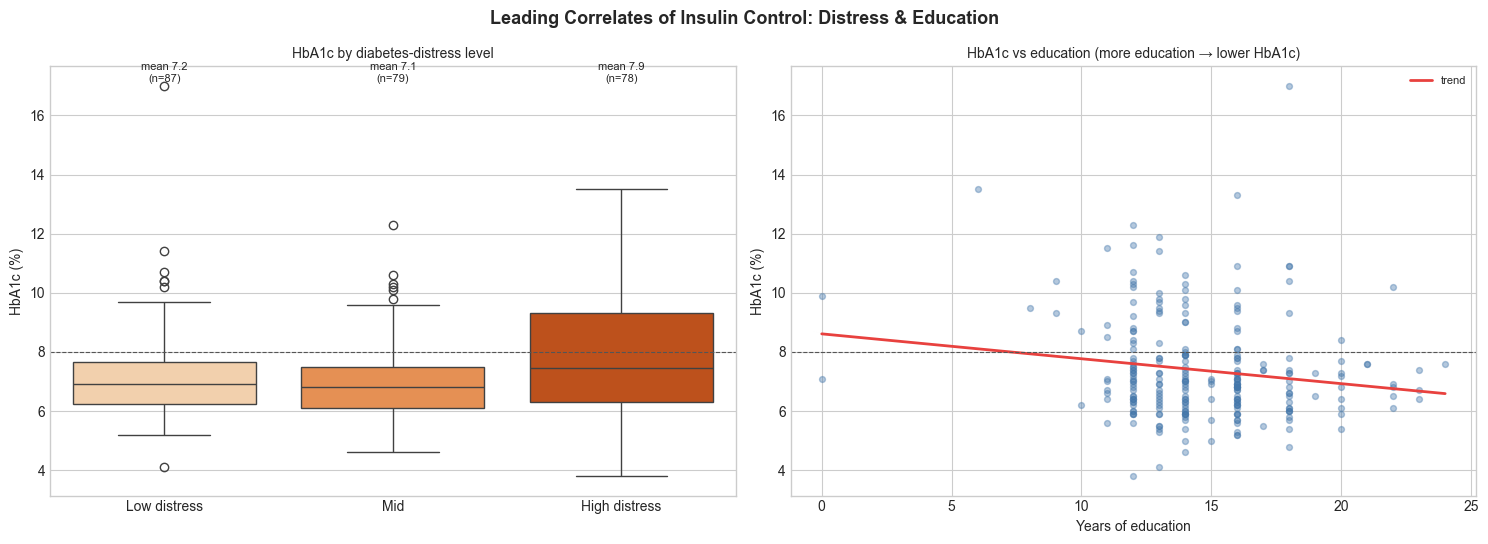

HbA1c by diabetes-distress tertile:
               mean  count
distress_band             
Low distress  7.220     87
Mid           7.060     79
High distress 7.890     78


In [6]:
# ── Analysis 3: Spotlight — Diabetes Distress & Education ──────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Leading Correlates of Insulin Control: Distress & Education', fontsize=13, fontweight='bold')

# Panel A: HbA1c by PAID-5 tertile
sp = ins[['paid_total', 'hba1c']].dropna()
sp['distress_band'] = pd.qcut(sp['paid_total'], 3, labels=['Low distress', 'Mid', 'High distress'], duplicates='drop')
band_mean = sp.groupby('distress_band', observed=True)['hba1c'].agg(['mean', 'count'])
sns.boxplot(data=sp, x='distress_band', y='hba1c', ax=axes[0], palette='Oranges')
axes[0].axhline(HBA1C_POOR, color='#555', ls='--', lw=0.8)
axes[0].set_xlabel(''); axes[0].set_ylabel('HbA1c (%)')
axes[0].set_title('HbA1c by diabetes-distress level', fontsize=10)
for i, (idx, r) in enumerate(band_mean.iterrows()):
    axes[0].text(i, axes[0].get_ylim()[1]*0.97, f"mean {r['mean']:.1f}\n(n={int(r['count'])})", ha='center', fontsize=8)

# Panel B: HbA1c vs years of education (scatter + binned trend)
se = ins[['education', 'hba1c']].dropna()
axes[1].scatter(se['education'], se['hba1c'], s=18, alpha=0.4, color='#4477AA')
if len(se) > 10:
    z = np.polyfit(se['education'], se['hba1c'], 1)
    xs = np.linspace(se['education'].min(), se['education'].max(), 50)
    axes[1].plot(xs, z[0]*xs + z[1], color='#E8413E', lw=2, label='trend')
axes[1].axhline(HBA1C_POOR, color='#555', ls='--', lw=0.8)
axes[1].set_xlabel('Years of education'); axes[1].set_ylabel('HbA1c (%)')
axes[1].set_title('HbA1c vs education (more education → lower HbA1c)', fontsize=10); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print('HbA1c by diabetes-distress tertile:')
print(band_mean.round(2).to_string())

---
## 7. Analysis 4 — Well-Controlled vs Poorly-Controlled Insulin Patients

> **Question**: Split insulin patients into well-controlled (HbA1c < 7%) vs poorly-controlled
> (≥ 8%). Which factors actually differ between these two groups? A binary contrast can be more
> sensitive than a continuous correlation in a small sample.
>
> **Method**: Mann-Whitney U comparing each predictor between the two control groups, FDR-corrected.

Well-controlled (HbA1c < 7.0%): n=122  |  Poorly-controlled (≥ 8.0%): n=60

=== Well vs Poorly controlled: predictor differences ===
(delta = poorly-controlled mean − well-controlled mean)
                 predictor  mean_well  mean_poor  delta_poor_minus_well     p  p_fdr  fdr_sig
        Years of education     15.160     13.420                 -1.730 0.001  0.010     True
Diabetes distress (PAID-5)      4.830      7.930                  3.110 0.002  0.010     True
     Depression (CES-D-10)      7.170      9.450                  2.280 0.011  0.040     True
               Age (years)     61.520     58.230                 -3.280 0.031  0.086    False
               Daily steps   6097.100   7814.350               1717.250 0.062  0.137    False
                       BMI     33.010     36.240                  3.220 0.127  0.233    False
         Comorbidity count      6.390      5.800                 -0.590 0.264  0.394    False
              Stress level     28.670     31.420           

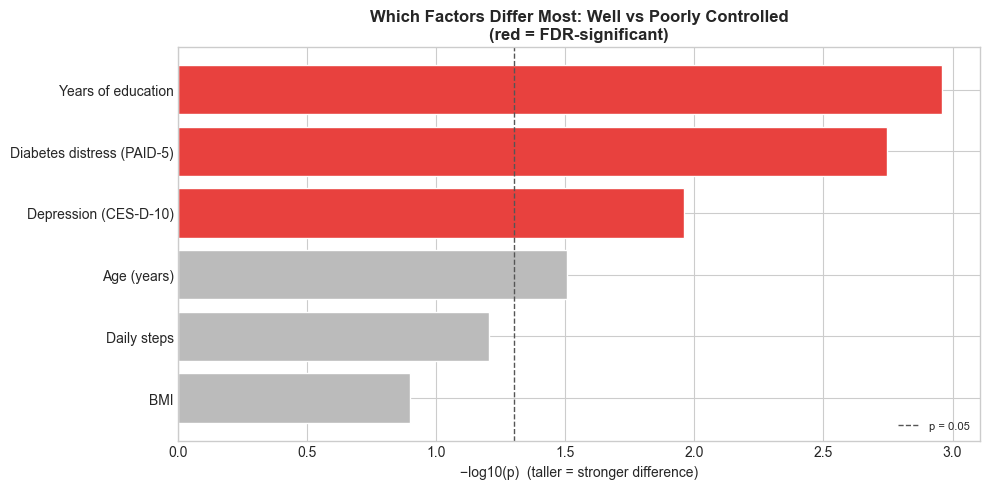

In [7]:
# ── Analysis 4: Well- vs Poorly-Controlled Insulin Patients ───────
well = ins[ins['hba1c'] < HBA1C_WELL]
poor = ins[ins['hba1c'] >= HBA1C_POOR]
print(f'Well-controlled (HbA1c < {HBA1C_WELL}%): n={len(well)}  |  '
      f'Poorly-controlled (≥ {HBA1C_POOR}%): n={len(poor)}')

rows = []
for col, label in PREDICTORS.items():
    if col not in ins.columns:
        continue
    a = well[col].dropna(); b = poor[col].dropna()
    if len(a) < 10 or len(b) < 10:
        continue
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    rows.append({'predictor': label, 'n_well': len(a), 'n_poor': len(b),
                 'mean_well': round(a.mean(), 2), 'mean_poor': round(b.mean(), 2),
                 'delta_poor_minus_well': round(b.mean() - a.mean(), 2), 'p': round(p, 4)})
wdf = pd.DataFrame(rows)
_, wdf['p_fdr'], _, _ = multipletests(wdf['p'], method='fdr_bh')
wdf['p_fdr'] = wdf['p_fdr'].round(3)
wdf['fdr_sig'] = wdf['p_fdr'] < 0.05
wdf = wdf.reindex(wdf['p'].sort_values().index).reset_index(drop=True)
print('\n=== Well vs Poorly controlled: predictor differences ===')
print('(delta = poorly-controlled mean − well-controlled mean)')
print(wdf[['predictor', 'mean_well', 'mean_poor', 'delta_poor_minus_well', 'p', 'p_fdr', 'fdr_sig']].to_string(index=False))

# ── Visualisation: top differences ──
top = wdf.head(6).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E8413E' if s else '#bbbbbb' for s in top['fdr_sig']]
ax.barh(top['predictor'], top['p'].apply(lambda x: -np.log10(max(x, 1e-6))), color=colors, edgecolor='white')
ax.axvline(-np.log10(0.05), color='#555', ls='--', lw=1, label='p = 0.05')
ax.set_xlabel('−log10(p)  (taller = stronger difference)')
ax.set_title('Which Factors Differ Most: Well vs Poorly Controlled\n(red = FDR-significant)',
             fontsize=12, fontweight='bold'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 8. Analysis 5 — Multivariate Regression: What Holds Up Independently?

> **Question**: The candidate predictors overlap (e.g. distress and depression travel together).
> When put in one model, which factors *independently* predict HbA1c in insulin patients?
>
> **Method**: OLS regression of HbA1c on the best-covered predictors (standardized so coefficients
> are comparable): diabetes distress, education, depression, age, BMI, and comorbidity count.
> Standardized coefficients show each factor's independent pull on HbA1c.

OLS: HbA1c ~ paid_total + education + cesd_total + age + bmi + comorbidity_count  (standardized)   n=239, R²=0.056

                 predictor  std_coef     p   sig
Diabetes distress (PAID-5)     0.252 0.075 False
        Years of education    -0.175 0.155 False
         Comorbidity count    -0.102 0.405 False
                       BMI     0.097 0.414 False
     Depression (CES-D-10)     0.065 0.653 False
               Age (years)     0.048 0.729 False

(Standardized coef = change in HbA1c %, in SD units of the predictor. Positive = worse control.)


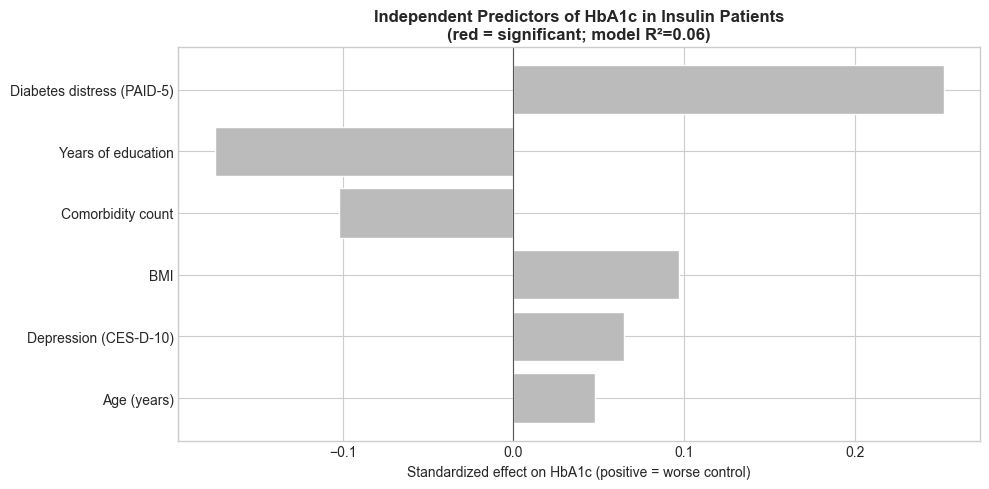

In [8]:
# ── Analysis 5: Multivariate Regression (standardized) ────────────
model_preds = ['paid_total', 'education', 'cesd_total', 'age', 'bmi', 'comorbidity_count']
reg = ins[['hba1c'] + model_preds].dropna().copy()
# standardize predictors (z-scores) for comparable coefficients
for c in model_preds:
    reg[c + '_z'] = (reg[c] - reg[c].mean()) / reg[c].std()
formula = 'hba1c ~ ' + ' + '.join(c + '_z' for c in model_preds)
mod = smf.ols(formula, data=reg).fit()

print(f'OLS: HbA1c ~ {" + ".join(model_preds)}  (standardized)   n={int(mod.nobs)}, R²={mod.rsquared:.3f}\n')
coef_rows = []
for c in model_preds:
    z = c + '_z'
    coef_rows.append({'predictor': PREDICTORS[c], 'std_coef': round(mod.params[z], 3),
                      'p': round(mod.pvalues[z], 4), 'sig': mod.pvalues[z] < 0.05})
cdf = pd.DataFrame(coef_rows).reindex(pd.Series([abs(r['std_coef']) for r in coef_rows]).sort_values(ascending=False).index).reset_index(drop=True)
print(cdf.to_string(index=False))
print(f'\n(Standardized coef = change in HbA1c %, in SD units of the predictor. '
      f'Positive = worse control.)')

# ── Visualisation: coefficient plot ──
cp = cdf.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E8413E' if s else '#bbbbbb' for s in cp['sig']]
ax.barh(cp['predictor'], cp['std_coef'], color=colors, edgecolor='white')
ax.axvline(0, color='#555', lw=0.8)
ax.set_xlabel('Standardized effect on HbA1c (positive = worse control)')
ax.set_title(f'Independent Predictors of HbA1c in Insulin Patients\n(red = significant; model R²={mod.rsquared:.2f})',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Key Findings

> Numbers come from the analysis cells above. **Headline: what separates well- from
> poorly-controlled insulin patients is *psychosocial* (education, diabetes distress, depression)
> — not behavior, weight, or comorbidity. The continuous signal is modest, but the well-vs-poor
> contrast is clear.**

1. **Control profile (Analysis 1):** insulin patients average **HbA1c 7.38%** — highest of all four groups (Healthy 5.5 → Insulin 7.4). About **49% are well-controlled (<7%)**, **24% poorly controlled (≥8%)**, and **17% very poor (≥9%)**.

2. **Univariate correlates (Analysis 2):** the leading correlates of *worse* HbA1c are **higher diabetes distress (ρ=+0.15)** and **lower education (ρ=−0.14)** — their bootstrap 95% CIs just exclude 0, but **neither survives FDR** correction. Behavioral (steps, sleep, stress) and clinical (age, BMI, comorbidity, cognition) factors show essentially no within-group signal.

3. **Spotlight (Analysis 3):** HbA1c is flat across low/mid distress (~7.1%) then jumps to **7.9% in the high-distress third**; it drifts down with more education.

4. **Well vs poorly controlled (Analysis 4) — the clearest result:** comparing well-controlled (<7%, n=122) vs poorly-controlled (≥8%, n=60), **three factors differ significantly (FDR<0.05)**, all psychosocial: poorly-controlled patients have **less education** (13.4 vs 15.2 yrs, FDR=0.010), **more diabetes distress** (PAID 7.9 vs 4.8, FDR=0.010), and **more depression** (CES-D 9.5 vs 7.2, FDR=0.040). BMI, comorbidity, cognition, sleep, and stress do **not** differ. (Poorly-controlled patients are also somewhat younger, age p=0.03 but not FDR-significant.)

5. **Regression (Analysis 5):** put together in one model, no single factor is independently significant — diabetes distress is the strongest pull (standardized +0.25, p=0.075) — and the model explains only ~6% of HbA1c variation (R²=0.056). The psychosocial factors overlap with each other, and most of what drives control isn't captured by these variables.

**Key takeaway:** in insulin-dependent patients, poor control travels with **lower education and higher emotional burden (diabetes distress and depression)** rather than with behavior or disease burden — pointing toward distress- and education-aware support. The small sample (n≈248) means these are strong *leads to confirm* in a larger insulin cohort, not definitive drivers.